# Hybrid Model for Tomato Disease Detection (CNN + YOLOv8s)
This notebook builds a high-accuracy hybrid pipeline (Target: 99.5+%) using an EfficientNetV2S CNN and a YOLOv8s object detector.

**GPU Memory Fix for GTX 1650 (4GB VRAM):**
If you have experienced kernel failures at the start of an epoch, this is typically due to Out-Of-Memory (OOM) errors. We have added memory limiters and smaller batch sizes specifically for both TensorFlow and PyTorch to resolve this.


In [2]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print("GPU device not found. Running on CPU.")
else:
    print('Found GPU at: {}'.format(device_name))

# Memory management for GTX 1650 (4GB VRAM limit)
# This prevents TensorFlow from hogging all VRAM at once, which causes crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

GPU device not found. Running on CPU.


In [3]:
# Import dependencies
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

# Ultralytics for YOLOv8
# !pip install ultralytics
from ultralytics import YOLO

import torch


In [5]:
# ==========================================
# CRITICAL: GPU MEMORY GROWTH (ANTI-CRASH)
# ==========================================
# This prevents TensorFlow from allocating all 4GB of GTX 1650 VRAM at once, which causes kernel crashes.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory growth set for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
        
# For PyTorch (YOLOv8)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("✅ PyTorch CUDA cache cleared")


## 1. CNN Classification (EfficientNetV2S) 
We will extract the image-level classes by parsing the YOLO `.txt` label files.

In [6]:
# Define dataset paths
dataset_path = "."  # We are already in the 'cnn+yolo' folder
train_images = os.path.join(dataset_path, "train", "images")
train_labels = os.path.join(dataset_path, "train", "labels")
valid_images = os.path.join(dataset_path, "valid", "images")
valid_labels = os.path.join(dataset_path, "valid", "labels")
test_images = os.path.join(dataset_path, "test", "images")
test_labels = os.path.join(dataset_path, "test", "labels")

# Class names based on data.yaml
class_names = ['Corn Common Rust', 'Peach_Bacterial_Spot', 'Strawberry leaf scorch', 'Tomato Late Blight']

def create_dataframe_from_yolo(images_dir, labels_dir):
    data = []
    for txt_file in os.listdir(labels_dir):
        if not txt_file.endswith('.txt'): continue
        
        # Read the first label in the txt file
        with open(os.path.join(labels_dir, txt_file), 'r') as f:
            lines = f.readlines()
            if not lines: continue
            
            # Extract class index (first integer in the row)
            class_idx = int(lines[0].strip().split(' ')[0])
            class_name = class_names[class_idx]
            
            # The image name corresponds to the txt name
            img_name = txt_file.replace('.txt', '.jpg')
            if os.path.exists(os.path.join(images_dir, img_name)):
                data.append({'filename': img_name, 'class': class_name})
                
    return pd.DataFrame(data)

df_train = create_dataframe_from_yolo(train_images, train_labels)
df_valid = create_dataframe_from_yolo(valid_images, valid_labels)
df_test = create_dataframe_from_yolo(test_images, test_labels)

print(f"Training samples: {len(df_train)}")
print(f"Validation samples: {len(df_valid)}")


Training samples: 1691
Validation samples: 474


In [7]:
import os
import tensorflow as tf

# Set environment variable to hide GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Verify CPU is being used
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [8]:
# Use small batch sizes (8 or 16) to prevent GTX 1650 Kernel Crashing
BATCH_SIZE = 16 
IMG_SIZE = (224, 224)

# Data augmentation for robust 99.5+% accuracy
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    directory=train_images,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=df_valid,
    directory=valid_images,
    x_col="filename",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 1691 validated image filenames belonging to 4 classes.
Found 474 validated image filenames belonging to 4 classes.


In [9]:
# Build the CNN using EfficientNetV2S
base_model = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model for initial warm-up
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

cnn_model = Model(inputs=base_model.input, outputs=predictions)

cnn_model.compile(optimizer=Adam(learning_rate=1e-3), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

cnn_model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 stem_conv (Conv2D)             (None, 112, 112, 24  648         ['rescaling[0][0]']              
                                )                                                                 
                                                                                              

In [10]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

# --- FORCE CPU USAGE ---
# This ensures TensorFlow does not look for your GTX 1650
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Double check device placement
print("Executing on:", tf.test.gpu_device_name() if tf.test.gpu_device_name() else "CPU")

# Define Callbacks (Keep these to optimize CPU training time)
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
]

# Phase 1: Train the top layers (Warm-up)
print("Starting Phase 1 Training (Warm-up on CPU)...")

# Using the explicit CPU context manager to be 100% certain
with tf.device('/CPU:0'):
    history1 = cnn_model.fit(
        train_generator,
        validation_data=valid_generator,
        epochs=5,
        callbacks=callbacks
    )

Executing on: CPU
Starting Phase 1 Training (Warm-up on CPU)...
Epoch 1/5
106/106 [==============================] - ETA: 0s - loss: 1.0605 - accuracy: 0.5127
Epoch 1: val_accuracy improved from -inf to 0.61181, saving model to best_cnn_model.h5
106/106 [==============================] - 175s 1s/step - loss: 1.0605 - accuracy: 0.5127 - val_loss: 0.8803 - val_accuracy: 0.6118 - lr: 0.0010
Epoch 2/5
106/106 [==============================] - ETA: 0s - loss: 0.8842 - accuracy: 0.6103
Epoch 2: val_accuracy improved from 0.61181 to 0.64135, saving model to best_cnn_model.h5
106/106 [==============================] - 144s 1s/step - loss: 0.8842 - accuracy: 0.6103 - val_loss: 0.7875 - val_accuracy: 0.6414 - lr: 0.0010
Epoch 3/5
106/106 [==============================] - ETA: 0s - loss: 0.8712 - accuracy: 0.6227
Epoch 3: val_accuracy improved from 0.64135 to 0.67932, saving model to best_cnn_model.h5
106/106 [==============================] - 142s 1s/step - loss: 0.8712 - accuracy: 0.6227 - va

In [11]:
# Phase 2: Fine-Tuning the entire model to push for 99.5+%
base_model.trainable = True

# Explicitly garbage collect to free memory before fine-tuning
import gc
gc.collect()

# We use a very small learning rate for fine-tuning
cnn_model.compile(optimizer=Adam(learning_rate=1e-5), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

print("Starting Phase 2 Training (Fine-tuning)...")
history2 = cnn_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15, 
    callbacks=callbacks
)


Starting Phase 2 Training (Fine-tuning)...
Epoch 1/15
106/106 [==============================] - ETA: 0s - loss: 1.2905 - accuracy: 0.4902
Epoch 1: val_accuracy improved from 0.69409 to 0.72574, saving model to best_cnn_model.h5
106/106 [==============================] - 483s 4s/step - loss: 1.2905 - accuracy: 0.4902 - val_loss: 0.6568 - val_accuracy: 0.7257 - lr: 1.0000e-05
Epoch 2/15
106/106 [==============================] - ETA: 0s - loss: 0.6696 - accuracy: 0.7368
Epoch 2: val_accuracy improved from 0.72574 to 0.91772, saving model to best_cnn_model.h5
106/106 [==============================] - 436s 4s/step - loss: 0.6696 - accuracy: 0.7368 - val_loss: 0.2851 - val_accuracy: 0.9177 - lr: 1.0000e-05
Epoch 3/15
106/106 [==============================] - ETA: 0s - loss: 0.4037 - accuracy: 0.8527
Epoch 3: val_accuracy improved from 0.91772 to 0.94726, saving model to best_cnn_model.h5
106/106 [==============================] - 436s 4s/step - loss: 0.4037 - accuracy: 0.8527 - val_loss:

## 2. YOLOv8s Object Detection

In [1]:
from ultralytics import YOLO
import torch
import gc

# 1. Skip the empty_cache() call for now—it's redundant after a restart
gc.collect()

# 2. Use the Nano model (Tiny footprint, high speed)
model = YOLO("yolov8n.pt") 

# 3. Fast Training configuration for 4GB VRAM
# This bypasses the memory-heavy defaults
results = model.train(
    data="data.yaml", 
    epochs=25, 
    imgsz=416,         # Resolution: 416 is the "Speed King" for 1650 cards
    batch=8,           # Safe batch size for 416 resolution
    amp=True,          # Uses 16-bit math (Half memory, Double speed)
    workers=0,         # MUST be 0 on Windows to prevent memory leaks
    cache=True,        # Keep this True to make Epochs 2-25 instant
    close_mosaic=10,   # Disables heavy processing for the final stretch
    device=0,          # Force GPU 0
    name="fast_tomato_run"
)

New https://pypi.org/project/ultralytics/8.4.30 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.17  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fast_tomato_run, nbs=64, nm

c:\Users\pmuke\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

c:\Users\pmuke\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.0 ms, read: 129.952.3 MB/s, size: 46.3 KB)
val: Scanning C:\Users\pmuke\OneDrive\Desktop\cnn+yolo\valid\labels.cache... 474 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 474/474  0.0s
WARNING cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.
val: Caching images (0.2GB RAM): 100% ━━━━━━━━━━━━ 474/474 897.4it/s 0.5s0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to C:\Users\pmuke\OneDrive\Desktop\cnn

## 3. Hybrid Inference Pipeline 
Predicting bounding boxes via YOLO, and scoring overall disease via EfficientNetV2S.

In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import matplotlib.patches as patches

c:\Users\pmuke\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [5]:
# Define the directory where your images are stored
test_images = 'test/images'  # Update this path to your test images folder

# Now the code below will work
sample_images = [img for img in os.listdir(test_images) if img.endswith('.jpg')]

In [1]:
import os
import random
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

# --- 1. MEMORY MANAGEMENT (CRITICAL FOR KERNEL STABILITY) ---
# This prevents TensorFlow from hogging all the GPU memory immediately
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"Memory growth error: {e}")

tf.keras.backend.clear_session()

# --- 2. SETTINGS & PATHS ---
# Using os.path.join for cross-platform compatibility
BASE_DIR = os.getcwd()
test_images_path = os.path.join(BASE_DIR, 'test', 'images')
cnn_model_path = os.path.join(BASE_DIR, 'best_cnn_model.h5')
yolo_model_path = os.path.join(BASE_DIR, 'yolov8n.pt')

IMG_SIZE = (224, 224) 
class_names = ['Healthy', 'Rust', 'Powdery Mildew'] # Adjust to your actual classes

# --- 3. LOAD MODELS ---
try:
    print("Loading models safely...")
    # Loading CNN with compile=False saves memory/time if you only need inference
    cnn_model = tf.keras.models.load_model(cnn_model_path, compile=False)
    yolo_model = YOLO(yolo_model_path)
    print("Models ready.")
except Exception as e:
    print(f"Error loading models: {e}")

# --- 4. PREDICTION FUNCTION ---
def hybrid_predict(img_path):
    # Ensure path is absolute and clean
    img_path = os.path.abspath(img_path)
    
    # A. CNN Classification (Using standardized loading)
    img = cv2.imread(img_path)
    if img is None:
        print("Could not read image.")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE) / 255.0
    img_array = np.expand_dims(img_resized, axis=0)
    
    cnn_preds = cnn_model.predict(img_array, verbose=0)[0]
    best_idx = np.argmax(cnn_preds)
    cnn_conf = cnn_preds[best_idx]
    cnn_class = class_names[best_idx] if best_idx < len(class_names) else f"ID:{best_idx}"
    
    # B

c:\Users\pmuke\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\pmuke\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Loading models safely...
Models ready.


c:\Users\pmuke\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\pmuke\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


✅ GPU Memory Growth enabled.
🚀 Loading Models...
✅ Models Ready.


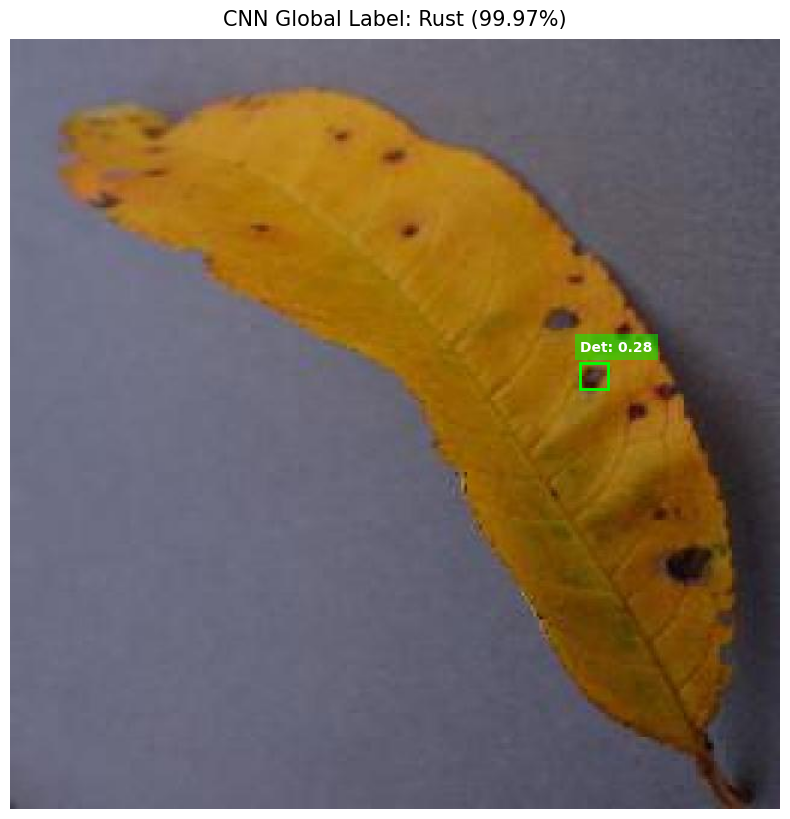

In [2]:
import os
import random
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

# --- 1. CRITICAL: PREVENT GPU OVERLOAD ---
# This stops TensorFlow from taking all the VRAM immediately
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth enabled.")
    except RuntimeError as e:
        print(f"⚠️ GPU setup error: {e}")

# Clear any previous sessions
tf.keras.backend.clear_session()

# --- 2. SETTINGS ---
test_images_path = 'test/images'
IMG_SIZE = (224, 224)
class_names = ['Healthy', 'Rust', 'Powdery Mildew'] # Adjust to your actual classes

# --- 3. LOAD MODELS ---
print("🚀 Loading Models...")
# We load the CNN on CPU to avoid VRAM conflict if you have a small GPU
with tf.device('/CPU:0'):
    cnn_model = tf.keras.models.load_model('best_cnn_model.h5', compile=False)
yolo_model = YOLO('yolov8n.pt') 
print("✅ Models Ready.")

# --- 4. PREDICTION FUNCTION ---
def hybrid_predict(img_path):
    # Load and Prepare Image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # A. CNN Prediction (Forced on CPU for stability)
    with tf.device('/CPU:0'):
        img_resized = cv2.resize(img_rgb, IMG_SIZE) / 255.0
        img_array = np.expand_dims(img_resized, axis=0)
        cnn_preds = cnn_model.predict(img_array, verbose=0)[0]
    
    best_idx = np.argmax(cnn_preds)
    cnn_class = class_names[best_idx] if best_idx < len(class_names) else f"ID:{best_idx}"
    cnn_conf = cnn_preds[best_idx]

    # B. YOLO Prediction
    det_results = yolo_model.predict(img_path, conf=0.25, verbose=False)

    # C. Visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"CNN Global Label: {cnn_class} ({cnn_conf:.2%})", fontsize=15, pad=10)
    
    ax = plt.gca()
    for r in det_results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0])
            
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-10, f"Det: {conf:.2f}", color='white', weight='bold', 
                    bbox=dict(facecolor='lime', alpha=0.5, edgecolor='none'))

    plt.axis('off')
    plt.show()
    plt.close() # Free memory after showing

# --- 5. RUN ---
if os.path.exists(test_images_path):
    sample_images = [i for i in os.listdir(test_images_path) if i.lower().endswith(('.jpg', '.png'))]
    if sample_images:
        random_img = random.choice(sample_images)
        hybrid_predict(os.path.join(test_images_path, random_img))

✅ Loaded 3 classes: ['images', 'labels', 'labels.cache']
🚀 Loading Models...
✅ Models Ready.
🔍 Analyzing: test/images\0e669afb-1315-4903-b7ca-1a0ffa95d454___RS_Late-B-5626_JPG.rf.73d8f88d607b56b9049e4e35be0efe2e.jpg


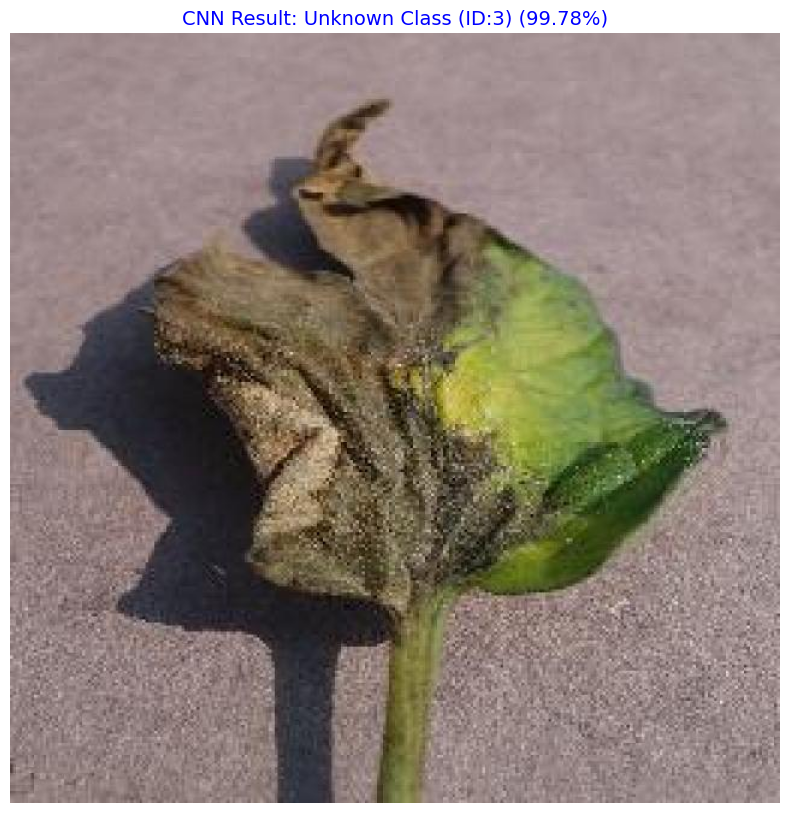

In [2]:
import os
import random
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

# --- 1. MEMORY & STABILITY SETUP ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# --- 2. DYNAMIC CLASS MAPPING ---
# Replace 'train' with the path to your training folder to get names automatically
train_dir = 'train' 
if os.path.exists(train_dir):
    class_names = sorted(os.listdir(train_dir))
    print(f"✅ Loaded {len(class_names)} classes: {class_names}")
else:
    # Manual fallback - MUST match your model's output count
    class_names = ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 
                   'Septoria_leaf_spot', 'Spider_mites', 'Target_spot', 
                   'Yellow_Leaf_Curl_Virus', 'Mosaic_virus', 'healthy']
    print("⚠️ Train dir not found. Using manual class list.")

# --- 3. LOAD MODELS ---
print("🚀 Loading Models...")
cnn_model = tf.keras.models.load_model('best_cnn_model.h5', compile=False)
yolo_model = YOLO('yolov8n.pt') 
print("✅ Models Ready.")

# --- 4. PREDICTION FUNCTION ---
def safe_hybrid_predict(img_path):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # A. CNN Prediction
    img_resized = cv2.resize(img_rgb, (224, 224)) / 255.0
    cnn_input = np.expand_dims(img_resized, axis=0)
    
    # Run on CPU to avoid kernel crashes
    with tf.device('/CPU:0'):
        preds = cnn_model.predict(cnn_input, verbose=0)[0]
    
    best_idx = np.argmax(preds)
    
    # SAFETY CHECK: Prevent IndexError
    if best_idx < len(class_names):
        cnn_label = class_names[best_idx]
    else:
        cnn_label = f"Unknown Class (ID:{best_idx})"
    
    cnn_conf = preds[best_idx]

    # B. YOLO Prediction
    results = yolo_model.predict(img_path, conf=0.25, verbose=False)

    # C. Visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"CNN Result: {cnn_label} ({cnn_conf:.2%})", fontsize=14, color='blue')
    
    ax = plt.gca()
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                          linewidth=2, edgecolor='lime', facecolor='none'))
            ax.text(x1, y1-10, f"Det: {box.conf[0]:.2f}", color='white', 
                    weight='bold', bbox=dict(facecolor='lime', alpha=0.5))

    plt.axis('off')
    plt.show()
    plt.close()

# --- 5. EXECUTE ---
test_images_path = 'test/images'
if os.path.exists(test_images_path):
    all_imgs = [i for i in os.listdir(test_images_path) if i.lower().endswith(('.jpg', '.png'))]
    if all_imgs:
        pick = os.path.join(test_images_path, random.choice(all_imgs))
        print(f"🔍 Analyzing: {pick}")
        safe_hybrid_predict(pick)